**Rhodium Hydrogenation of Enamides TSFF Parameterized by a new Hybrid Optimizer**

Rh Hyd Enamides TSFF as a test case for the use of a new Hybrid Particle Swarm-Differential Evolution Optimization Algorithm (hybrid_optimizer) developed by Mikaela Farrugia (github: @mmfarrugia) under Olaf Wiest & Paul Helquist.

TODO clean up this

In [1]:
import os
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np
import sys
from matplotlib import animation, rc
from IPython.display import HTML, Image
import seaborn
import pickle
import pandas as pd

seaborn.set_theme(style="whitegrid", palette='pastel')

#src_dir = os.path.abspath("/home/mmfarrugia/repos/q2mm/q2mm")
sys.path.append("/home/mfarrugi/repos/q2mm/rh-hybrid/schrodinger.ve/lib/python3.8/site-packages/q2mm-0.0.0-py3.8.egg")

#from hybrid_optimizer import PSO_GA
import q2mm.hybrid_optimizer as hybrid_optimizer
#from q2mm.hybrid_optimizer import PSO_GA
from tools.plotters import plot_cost_history, plot_contour, plot_surface, plot_summary, Mesher, Designer
from ff_plotting import plot_param_history




All are done with 8 workers, 10 particles/TSFF candidates, with 0.001 convergence criteria, run for loop cycles of 50 iter maximum with 3 technical replicates run for each case. Further information regarding the settings, files, and parameters used in the optimizations can be found in their respective directories under the README.txt file.

All hyperparameters are derived from literature **INCLUDE REFS** and use either the TIGHT_OPT_CONFIG or GLOBAL_OPT_CONFIG of HO.

In [2]:
num_particles = 10
cycle_iter_length = 50
num_workers = 8
convergence_criteria = 0.001
num_tech_replicates = 3
num_params = 31

**Start: FCs = 0.5 + Donoghue charges**

Original Score: 2.676

In [3]:
static_score = 2.676

In [4]:
base_directory = '/home/mfarrugi/repos/q2mm/rh-hybrid/q_fuerza/500_untapered_HO'
directory_list = ['1', '2', '3']

(878, 10, 31)
(878, 10)
(615, 10, 31)
(615, 10)
(970, 10, 31)
(970, 10)


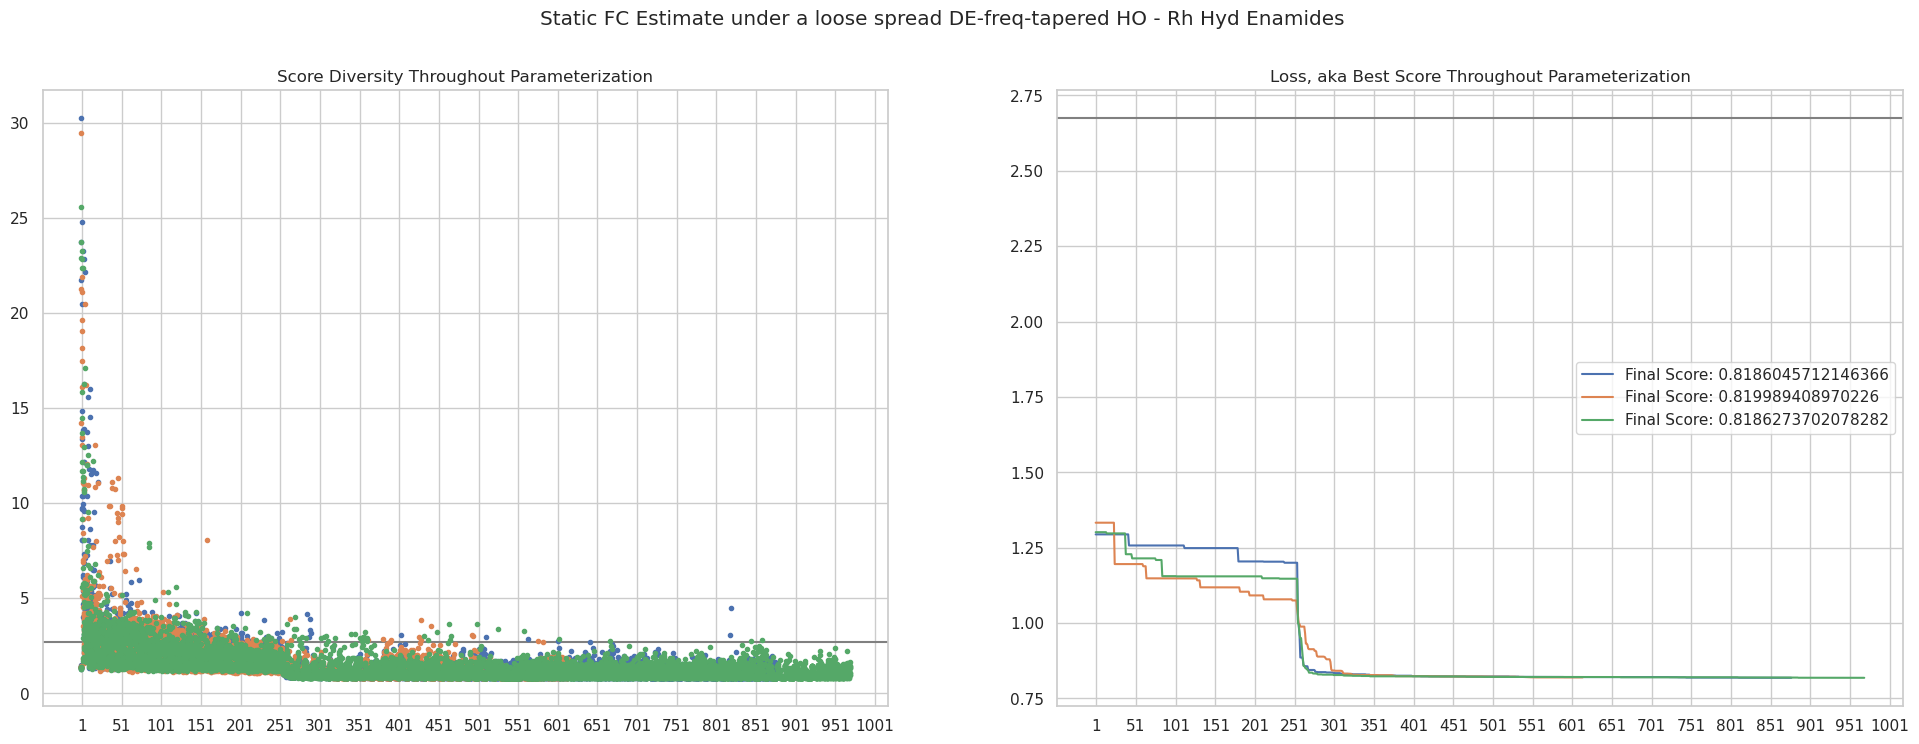

In [5]:
%matplotlib inline
# HYBRID NO TAPER
fig, ax = plt.subplots(1, 2, figsize=(24, 8))
fig.suptitle('Static FC Estimate under a loose spread DE-freq-tapered HO - Rh Hyd Enamides')
ax[0].set_title('Score Diversity Throughout Parameterization')
ax[1].set_title('Loss, aka Best Score Throughout Parameterization')

ax[0].axhline(y=static_score, color='gray')
ax[1].axhline(y=static_score, color='gray')

for directory in directory_list:

    swarm_history_file = open(os.path.join(base_directory, directory, 'hybrid_opt_history.bin'), 'rb')
    swarm_history = pickle.load(swarm_history_file)
    swarm_history_file.close()
    #print((swarm_history['X'][0][0][2]))
    #print([ff[0][2] for ff in [iter for iter in swarm_history['X']]])
    #print(np.array(swarm_history['X']))
    X_history = np.array(swarm_history['X'])#.reshape((num_iters, num_ffs, num_params)))
    print(np.shape(X_history))
    print(np.shape(X_history[:,:,0]))
    #print(type(swarm_history['X'][0]))
    #print(swarm_history['X'][:][:,0])
    num_iters = len(swarm_history['Y'])
    num_ffs = len(swarm_history['Y'][0])
    assert num_ffs == num_particles
    color = next(ax[0]._get_lines.prop_cycler)['color']
    Y_history = pd.DataFrame(np.array(swarm_history['Y']).reshape((num_iters, num_ffs)))
    ax[0].plot(Y_history.index, Y_history.values, '.', color=color)
    loss = Y_history.min(axis=1).cummin()
    loss.plot(kind='line', ax=ax[1], color=color, label='Final Score: '+str(loss.iloc[-1]))

ax[1].legend()

ax[0].xaxis.set_ticks(np.arange(1, ax[0].get_xlim()[1], cycle_iter_length))
ax[1].xaxis.set_ticks(np.arange(1, ax[0].get_xlim()[1], cycle_iter_length))

plt.show()

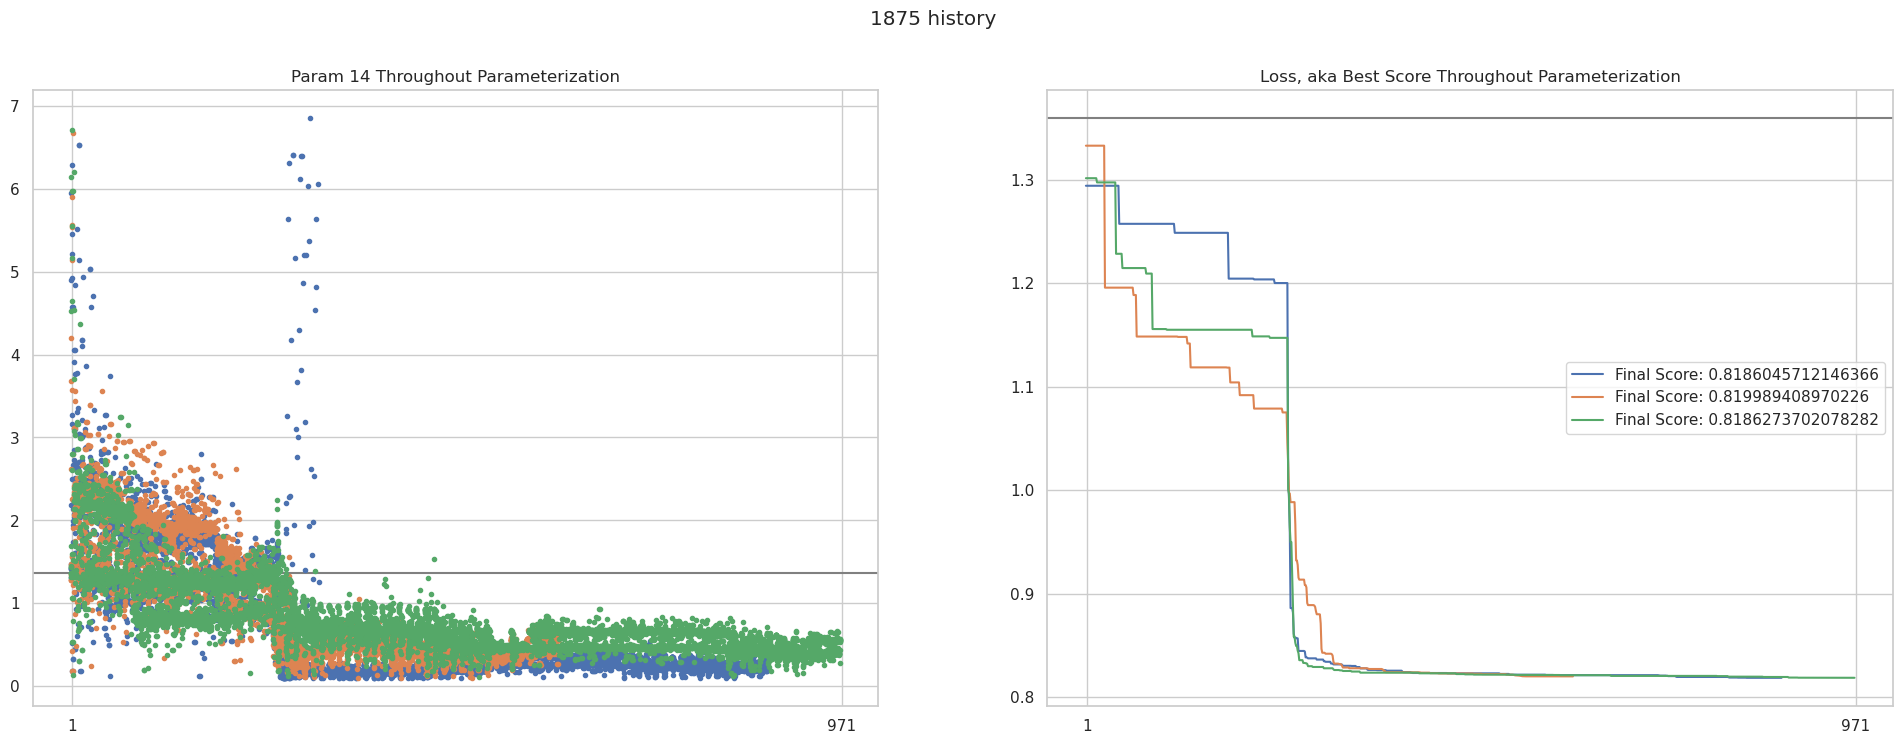

[]

In [6]:
plot_param_history(base_directory, directory_list, 14, '1875 history', num_iters, 1.36)